# ML Modeling: Linear Regression Analysis for GDM Association (Placenta)

## Overview
This notebook performs linear regression analysis to determine if there is a significant difference
in metabolite levels between GDM positive and non-GDM women, while accounting for covariates.
We analyze **placenta** metabolites and calculate effect sizes and adjusted p-values.


## Step 1-2: Set Up Big Loop for Each Metabolite (Placenta Data)

We will create a loop that iterates over each metabolite. For placenta data:
- Rows = samples  
- Columns = metabolites  
- For each metabolite i: extract metabolite[i] (all rows, ith column)
- Fit model: `lm(metabolite[i] ~ GDM + covariates)`


## Setup: Load Core Inputs (Self-Contained)

Loading:
- `placenta_matrix` from `PLACENTA_DATA_T`
- Covariates and supplements from `src/raw/mata2022_caco_mar242022.xlsx`
- `Sample` IDs from the placenta mapping file (for row alignment only)
- `covariate_matrix_num` (aligned to placenta sample order)
- Output directories for Placenta-specific CSV and image files


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
import statsmodels.api as sm


In [2]:
# Self-contained setup: load placenta metabolite matrix and build aligned covariate matrix

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from src.utils.config import PLACENTA_DATA_T, PLACENTA_ANNO, OUTPUTS_DIR

# 1) Load placenta metabolite matrix (rows=samples, columns=metabolites)
placenta_matrix = pd.read_csv(PLACENTA_DATA_T, index_col='Sample').astype(float)
placenta_matrix.index = placenta_matrix.index.astype(str)

# 2) Load raw maternal covariate file
src_dir = Path(PLACENTA_DATA_T).resolve().parents[2]
mata_path = src_dir / 'raw' / 'mata2022_caco_mar242022.xlsx'
if not mata_path.exists():
    raise FileNotFoundError(f'Required maternal covariate file not found: {mata_path}')

mata_df = pd.read_excel(mata_path)

# 3) Load Sample ID bridge from placenta mapping output (used only for sample alignment)
gdm_map_path = os.path.join(OUTPUTS_DIR, 'pca', 'output_csv', '06_pc_scores', 'placenta_mapped_with_pc1_pc2.csv')
if not os.path.exists(gdm_map_path):
    raise FileNotFoundError(f'Required mapping file not found: {gdm_map_path}')

sample_bridge = pd.read_csv(gdm_map_path)
required_bridge_cols = ['Sample', 'IDCode']
missing_bridge = [c for c in required_bridge_cols if c not in sample_bridge.columns]
if missing_bridge:
    raise ValueError(f'Mapping file missing required columns: {missing_bridge}')

sample_bridge = sample_bridge[required_bridge_cols].copy()
sample_bridge['Sample'] = sample_bridge['Sample'].astype(str).str.strip()
sample_bridge = sample_bridge[sample_bridge['Sample'].str.len() > 0]
sample_bridge['IDCode'] = pd.to_numeric(sample_bridge['IDCode'], errors='coerce')
sample_bridge = sample_bridge.dropna(subset=['IDCode']).drop_duplicates(subset=['Sample'], keep='first')

# 4) Merge raw maternal covariates to Sample IDs via IDCode
map_df = sample_bridge.merge(mata_df, on='IDCode', how='left')
map_df = map_df.drop_duplicates(subset=['Sample'], keep='first').set_index('Sample')

# 5) Resolve required covariates by aliases
covariate_aliases = {
    'maternal_age': ['Ma_age', 'maternal_age'],
    'bmi': ['pre_BMI_new', 'BMI', 'Ma_BMI'],
    'diet_protein': ['diet_protein', 'protein', 'protein_intake'],
    'diet_fruit_vegetables': ['diet_vegfruit', 'fruit_vegetable', 'fruit_veg'],
}
required_physical_activity_col = 'O2_PHYSACTIV'

selected_covariates = {}
for label, aliases in covariate_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_covariates[label] = selected

if required_physical_activity_col not in map_df.columns:
    phys_candidates = [
        c for c in map_df.columns
        if 'phys' in str(c).lower() or 'activ' in str(c).lower()
    ]
    raise ValueError(
        f"Required physical activity column '{required_physical_activity_col}' not found. "
        f'Candidates: {phys_candidates}'
    )
selected_covariates['physical_activity'] = required_physical_activity_col

# 6) Align covariate rows to placenta matrix row order
sample_order = placenta_matrix.index
ordered_source_cols = ['GDM'] + list(selected_covariates.values())
if 'GDM' not in map_df.columns:
    raise ValueError('GDM column not found after merging maternal covariates.')

covariate_matrix_raw = map_df.reindex(sample_order)[ordered_source_cols].copy()
covariate_matrix_raw.index.name = 'Sample'

rename_map = {'GDM': 'GDM'}
rename_map.update({src: label for label, src in selected_covariates.items()})
covariate_matrix_raw = covariate_matrix_raw.rename(columns=rename_map)

# 7) Type handling: GDM and physical_activity as categorical factors; others numeric
covariate_matrix_num = covariate_matrix_raw.copy()
gdm_numeric = pd.to_numeric(covariate_matrix_num['GDM'], errors='coerce')
covariate_matrix_num['GDM'] = pd.Categorical(gdm_numeric, categories=[0, 1])

# physical_activity source coding: 1=No, 2=Yes -> model coding: 0=No, 1=Yes
phys_numeric = pd.to_numeric(covariate_matrix_num['physical_activity'], errors='coerce')
phys_observed = set(phys_numeric.dropna().unique())
if phys_observed.issubset({1, 2}):
    phys_binary = phys_numeric.map({1: 0, 2: 1})
elif phys_observed.issubset({0, 1}):
    phys_binary = phys_numeric
else:
    phys_binary = pd.Series(
        np.where(phys_numeric.isna(), np.nan, (phys_numeric > 0).astype(int)),
        index=phys_numeric.index,
    )
phys_binary = pd.array(phys_binary, dtype='Int64')
covariate_matrix_num['physical_activity'] = pd.Categorical(phys_binary, categories=[0, 1])

numeric_covariates = [c for c in covariate_matrix_num.columns if c not in ['GDM', 'physical_activity']]
covariate_matrix_num[numeric_covariates] = covariate_matrix_num[numeric_covariates].apply(pd.to_numeric, errors='coerce')

cov_matrix = covariate_matrix_num.copy()

# Auto-discover samples with missing physical_activity (used as fallback in KNN cells)
_pa_numeric = pd.to_numeric(
    covariate_matrix_raw.get('physical_activity', pd.Series(dtype=float)), errors='coerce'
)
fallback_samples = covariate_matrix_raw.index[_pa_numeric.isna()].tolist()
print(f'Samples with missing physical_activity: {fallback_samples}')

# 8) Output directories
pl_csv_dir = os.path.join(OUTPUTS_DIR, 'ml_modeling', 'Placenta', 'Python_outputs', 'CSV')
pl_img_dir = os.path.join(OUTPUTS_DIR, 'ml_modeling', 'Placenta', 'Python_outputs', 'images')
os.makedirs(pl_csv_dir, exist_ok=True)
os.makedirs(pl_img_dir, exist_ok=True)

print('Setup complete')
print('Placenta matrix shape:', placenta_matrix.shape)
print('Covariate matrix shape:', cov_matrix.shape)
print('GDM dtype:', cov_matrix['GDM'].dtype)
print('physical_activity dtype:', cov_matrix['physical_activity'].dtype)
print('physical_activity levels (0=No, 1=Yes):', cov_matrix['physical_activity'].cat.categories.tolist())
print('Resolved numeric covariates:', numeric_covariates)
print('Maternal source file:', mata_path)
print('CSV output dir:', pl_csv_dir)
print('Images output dir:', pl_img_dir)


Samples with missing physical_activity: ['sample-13', 'sample-29', 'sample-40']
Setup complete
Placenta matrix shape: (40, 897)
Covariate matrix shape: (40, 6)
GDM dtype: category
physical_activity dtype: category
physical_activity levels (0=No, 1=Yes): [0, 1]
Resolved numeric covariates: ['maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables']
Maternal source file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/raw/mata2022_caco_mar242022.xlsx
CSV output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV
Images output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/images


In [3]:
placenta_matrix.head()


,1002002,1004006,107004,108004,108005,108015,109002,109011,1101006,1102005,...,675026,675027,675028,675029,676002,676003,676007,677004,677007,677011
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,1.067250,1.146871,1.005599,0.787917,1.028547,0.901608,1.022227,1.005848,1.017847,0.893673,...,0.992389,0.995633,1.003121,1.015811,1.050298,1.010108,1.008183,0.993579,1.052516,0.991678
sample-2,0.846538,0.985189,1.003932,0.964908,0.992848,1.010751,1.010744,0.999033,0.991056,0.893673,...,1.003757,1.023405,0.983785,1.008291,0.912968,0.985384,0.979877,0.970319,0.902791,1.002502
sample-3,0.928315,0.991967,0.970812,0.787917,1.028489,0.958734,0.995818,1.020683,0.999784,0.893673,...,0.999519,1.003467,0.991889,0.988243,0.986999,1.006392,1.016172,1.001665,1.001421,1.003265
sample-4,1.101470,1.096246,0.997856,0.805863,1.030684,0.928710,0.997960,0.983982,0.995086,0.893673,...,0.972489,0.975934,0.994323,0.986412,0.955030,0.983886,0.979119,0.977793,0.977029,0.979333
sample-5,1.145117,1.172380,1.018498,0.787917,1.043982,0.901608,1.052483,1.000493,0.980575,0.893673,...,1.013411,0.998258,0.999595,1.022783,0.931531,1.026713,1.006994,1.002254,0.899448,1.004080


In [4]:
import re as _re
from pathlib import Path as _Path
_si = pd.read_excel(
    _Path(PLACENTA_DATA_T).resolve().parents[2] / "raw" / "MetaPro_placenta_Jan2022.xlsx",
    sheet_name="Sample Info", header=0)
_label_map = dict(zip(_si["SAMPLE ID"].astype(str), _si["Tube Label"].astype(str)))
_tube = [_re.sub(r"^[A-Za-z]+", "", _label_map.get(s, "")) for s in cov_matrix.index]
_disp = cov_matrix.copy()
_disp.insert(0, "Tube_Label", _tube)
_disp.head(40)

,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,,
sample-1,20150,1,38,28.959000,6.15,17.00,0
sample-2,20284,0,34,28.040378,4.50,4.50,1
sample-3,20159,1,28,25.217359,3.25,4.50,1
sample-4,20256,0,28,24.242424,12.50,12.50,1
sample-5,20187,1,37,22.375680,8.50,24.00,0
sample-6,20219,0,32,20.195578,30.00,30.00,1
sample-7,20190,1,33,21.875000,14.65,21.00,0
sample-8,20225,0,32,21.303949,14.65,21.00,0
sample-9,20194,1,29,25.076193,2.40,3.65,0


In [5]:
import numpy as np

print('Missing values by covariate:')
print(covariate_matrix_num.isnull().sum())
print(f'\nTotal missing values: {covariate_matrix_num.isnull().sum().sum()}')


Missing values by covariate:
GDM                      0
maternal_age             0
bmi                      0
diet_protein             1
diet_fruit_vegetables    1
physical_activity        3
dtype: int64

Total missing values: 5


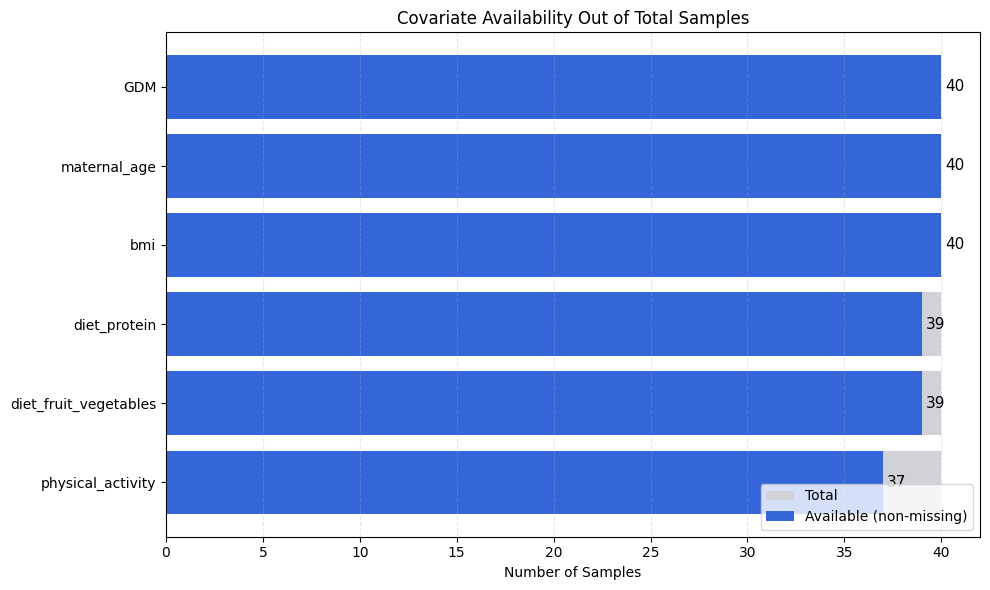

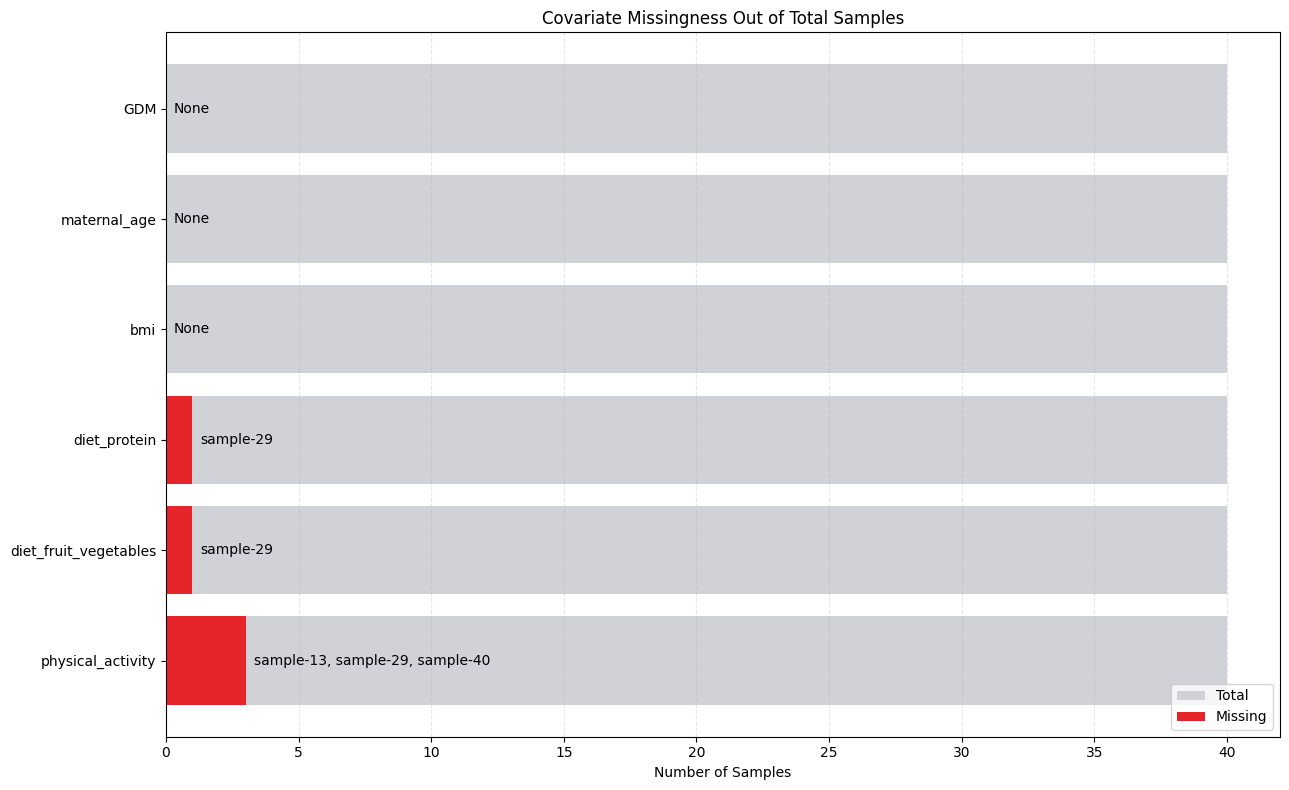

In [6]:
import matplotlib.pyplot as plt

total_n = len(cov_matrix)
missing_counts = cov_matrix.isna().sum()
available_counts = total_n - missing_counts

plot_order = available_counts.sort_values(ascending=False).index.tolist()

missing_sample_labels = {}
for col in plot_order:
    missing_samples = cov_matrix.index[cov_matrix[col].isna()].tolist()
    missing_sample_labels[col] = ', '.join(missing_samples) if missing_samples else 'None'

# 1) Availability
fig, ax = plt.subplots(figsize=(10, 6))
ypos = range(len(plot_order))
ax.barh(ypos, [total_n] * len(plot_order), color='#d0d2d8', label='Total')
ax.barh(ypos, [available_counts[c] for c in plot_order], color='#3465d9', label='Available (non-missing)')
ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel('Number of Samples')
ax.set_title('Covariate Availability Out of Total Samples')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(loc='lower right')
for i, c in enumerate(plot_order):
    ax.text(available_counts[c] + 0.2, i, f'{int(available_counts[c])}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'covariate_availability.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2) Missingness
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(ypos, [total_n] * len(plot_order), color='#d0d2d8', label='Total')
ax.barh(ypos, [missing_counts[c] for c in plot_order], color='#e5252a', label='Missing')
ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel('Number of Samples')
ax.set_title('Covariate Missingness Out of Total Samples')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(loc='lower right')
for i, c in enumerate(plot_order):
    ax.text(missing_counts[c] + 0.3, i, missing_sample_labels[c], va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'covariate_missingness.png'), dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import re as _re
from pathlib import Path as _Path
_si = pd.read_excel(
    _Path(PLACENTA_DATA_T).resolve().parents[2] / "raw" / "MetaPro_placenta_Jan2022.xlsx",
    sheet_name="Sample Info", header=0)
_label_map = dict(zip(_si["SAMPLE ID"].astype(str), _si["Tube Label"].astype(str)))
_tube = [_re.sub(r"^[A-Za-z]+", "", _label_map.get(s, "")) for s in cov_matrix.index]
_disp = cov_matrix.copy()
_disp.insert(0, "Tube_Label", _tube)
_disp.head(40)

,Tube_Label,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,,
sample-1,20150,1,38,28.959000,6.15,17.00,0
sample-2,20284,0,34,28.040378,4.50,4.50,1
sample-3,20159,1,28,25.217359,3.25,4.50,1
sample-4,20256,0,28,24.242424,12.50,12.50,1
sample-5,20187,1,37,22.375680,8.50,24.00,0
sample-6,20219,0,32,20.195578,30.00,30.00,1
sample-7,20190,1,33,21.875000,14.65,21.00,0
sample-8,20225,0,32,21.303949,14.65,21.00,0
sample-9,20194,1,29,25.076193,2.40,3.65,0


In [8]:
if 'maternal_age' not in cov_matrix.columns:
    raise KeyError("'maternal_age' column not found in cov_matrix")
maternal_age_mean = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce').mean()
print(f'Mean Maternal Age: {maternal_age_mean:.4f}')


Mean Maternal Age: 32.1500


In [9]:
if 'maternal_age' not in cov_matrix.columns:
    raise KeyError("'maternal_age' column not found in cov_matrix")
maternal_age_std = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce').std()
print(f'Standard Deviation of Maternal Age: {maternal_age_std:.4f}')


Standard Deviation of Maternal Age: 3.6130


In [10]:
maternal_age_series = pd.to_numeric(cov_matrix['maternal_age'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

summary_rows = []
for group_name, group_values in [
    ('Non-GDM', maternal_age_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM',     maternal_age_series[gdm_series.isin(['1', '1.0'])]),
    ('All',     maternal_age_series),
]:
    summary_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Mean_Maternal_Age': group_values.mean(),
        'SD_Maternal_Age':   group_values.std(),
    })

maternal_age_summary = pd.DataFrame(summary_rows)
print('Maternal Age Summary Table:')
display(maternal_age_summary)


Maternal Age Summary Table:


,Group,Total,Mean_Maternal_Age,SD_Maternal_Age
0,Non-GDM,22,31.000000,2.894987
1,GDM,18,33.555556,3.973770
2,All,40,32.150000,3.613011


In [11]:
bmi_series = pd.to_numeric(cov_matrix['bmi'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

bmi_rows = []
for group_name, group_values in [
    ('Non-GDM', bmi_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM',     bmi_series[gdm_series.isin(['1', '1.0'])]),
    ('All',     bmi_series),
]:
    bmi_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Mean_BMI': group_values.mean(),
        'SD_BMI':   group_values.std(),
    })

bmi_summary = pd.DataFrame(bmi_rows)
print('BMI Summary Table:')
display(bmi_summary)


BMI Summary Table:


,Group,Total,Mean_BMI,SD_BMI
0,Non-GDM,22,23.331892,3.568163
1,GDM,18,23.486673,3.257524
2,All,40,23.401543,3.389273


In [12]:
protein_series = pd.to_numeric(cov_matrix['diet_protein'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

protein_rows = []
for group_name, group_values in [
    ('Non-GDM', protein_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM',     protein_series[gdm_series.isin(['1', '1.0'])]),
    ('All',     protein_series),
]:
    protein_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Sum_Protein_Frequency':  group_values.sum(),
        'Mean_Protein_Frequency': group_values.mean(),
        'SD_Protein_Frequency':   group_values.std(),
    })

protein_summary = pd.DataFrame(protein_rows)
print('Protein Frequency Summary Table:')
display(protein_summary)


Protein Frequency Summary Table:


,Group,Total,Sum_Protein_Frequency,Mean_Protein_Frequency,SD_Protein_Frequency
0,Non-GDM,22,352.2,16.009091,6.618078
1,GDM,17,242.7,14.276471,7.028405
2,All,39,594.9,15.253846,6.764734


In [13]:
vegfruit_series = pd.to_numeric(cov_matrix['diet_fruit_vegetables'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

vegfruit_rows = []
for group_name, group_values in [
    ('Non-GDM', vegfruit_series[gdm_series.isin(['0', '0.0'])]),
    ('GDM',     vegfruit_series[gdm_series.isin(['1', '1.0'])]),
    ('All',     vegfruit_series),
]:
    vegfruit_rows.append({
        'Group': group_name,
        'Total': int(group_values.notna().sum()),
        'Sum_VegFruits_Frequency':  group_values.sum(),
        'Mean_VegFruits_Frequency': group_values.mean(),
        'SD_VegFruits_Frequency':   group_values.std(),
    })

vegfruit_summary = pd.DataFrame(vegfruit_rows)
print('Vegetables and Fruits Frequency Summary Table:')
display(vegfruit_summary)


Vegetables and Fruits Frequency Summary Table:


,Group,Total,Sum_VegFruits_Frequency,Mean_VegFruits_Frequency,SD_VegFruits_Frequency
0,Non-GDM,22,442.25,20.102273,6.781742
1,GDM,17,303.45,17.850000,7.861616
2,All,39,745.70,19.120513,7.260851


In [14]:
pa_series = pd.to_numeric(cov_matrix['physical_activity'], errors='coerce')
gdm_series = cov_matrix['GDM'].astype(str)

pa_summary_rows = []
for group_name, group_mask in [
    ('Non-GDM', gdm_series.isin(['0', '0.0'])),
    ('GDM',     gdm_series.isin(['1', '1.0'])),
    ('All',     pd.Series([True] * len(cov_matrix), index=cov_matrix.index)),
]:
    group_values = pa_series[group_mask].dropna()
    total = int(group_values.shape[0])
    yes_n = int((group_values == 1).sum())
    no_n  = int((group_values == 0).sum())
    pa_summary_rows.append({
        'Group': group_name,
        'Yes_n(%)': f'{yes_n} ({(100 * yes_n / total):.1f}%)' if total else '0 (0.0%)',
        'No_n(%)':  f'{no_n} ({(100 * no_n / total):.1f}%)'  if total else '0 (0.0%)',
        'Total': total,
    })

pa_summary = pd.DataFrame(pa_summary_rows)
print('Physical Activity in Last 3 Months Summary Table:')
display(pa_summary)


Physical Activity in Last 3 Months Summary Table:


,Group,Yes_n(%),No_n(%),Total
0,Non-GDM,9 (42.9%),12 (57.1%),21
1,GDM,8 (50.0%),8 (50.0%),16
2,All,17 (45.9%),20 (54.1%),37


In [15]:
combined_summary_rows = []

for _, row in maternal_age_summary.iterrows():
    combined_summary_rows.append({'Metric': 'Maternal Age', 'Group': row['Group'],
        'Total': int(row['Total']), 'Mean': row['Mean_Maternal_Age'], 'SD': row['SD_Maternal_Age'],
        'Sum': pd.NA, 'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA})

for _, row in bmi_summary.iterrows():
    combined_summary_rows.append({'Metric': 'BMI', 'Group': row['Group'],
        'Total': int(row['Total']), 'Mean': row['Mean_BMI'], 'SD': row['SD_BMI'],
        'Sum': pd.NA, 'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA})

for _, row in protein_summary.iterrows():
    combined_summary_rows.append({'Metric': 'Protein frequency (times/week)', 'Group': row['Group'],
        'Total': int(row['Total']), 'Mean': row['Mean_Protein_Frequency'],
        'SD': row['SD_Protein_Frequency'], 'Sum': row['Sum_Protein_Frequency'],
        'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA})

for _, row in vegfruit_summary.iterrows():
    combined_summary_rows.append({'Metric': 'Vegetables and fruits frequency (times/week)', 'Group': row['Group'],
        'Total': int(row['Total']), 'Mean': row['Mean_VegFruits_Frequency'],
        'SD': row['SD_VegFruits_Frequency'], 'Sum': row['Sum_VegFruits_Frequency'],
        'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA})

for _, row in pa_summary.iterrows():
    combined_summary_rows.append({'Metric': 'Physical Activity in last 3 months', 'Group': row['Group'],
        'Total': int(row['Total']), 'Mean': pd.NA, 'SD': pd.NA, 'Sum': pd.NA,
        'Yes_n(%)': row['Yes_n(%)'], 'No_n(%)': row['No_n(%)']})

combined_summary = pd.DataFrame(combined_summary_rows)
combined_summary = combined_summary[['Metric', 'Group', 'Total', 'Sum', 'Mean', 'SD', 'Yes_n(%)', 'No_n(%)']]

before_path = os.path.join(pl_csv_dir, 'Table1_before_cleaning.csv')
combined_summary.to_csv(before_path, index=False)
print(f'Saved Table1 before cleaning to: {before_path}')
display(combined_summary)


Saved Table1 before cleaning to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/Table1_before_cleaning.csv


,Metric,Group,Total,Sum,Mean,SD,Yes_n(%),No_n(%)
0,Maternal Age,Non-GDM,22,<NA>,31.0,2.894987,<NA>,<NA>
1,Maternal Age,GDM,18,<NA>,33.555556,3.97377,<NA>,<NA>
2,Maternal Age,All,40,<NA>,32.15,3.613011,<NA>,<NA>
3,BMI,Non-GDM,22,<NA>,23.331892,3.568163,<NA>,<NA>
4,BMI,GDM,18,<NA>,23.486673,3.257524,<NA>,<NA>
5,BMI,All,40,<NA>,23.401543,3.389273,<NA>,<NA>
6,Protein frequency (times/week),Non-GDM,22,352.2,16.009091,6.618078,<NA>,<NA>
7,Protein frequency (times/week),GDM,17,242.7,14.276471,7.028405,<NA>,<NA>
8,Protein frequency (times/week),All,39,594.9,15.253846,6.764734,<NA>,<NA>
9,Vegetables and fruits frequency (times/week),Non-GDM,22,442.25,20.102273,6.781742,<NA>,<NA>


In [16]:
impute_cols = ['diet_protein', 'diet_fruit_vegetables']

before_missing = cov_matrix[impute_cols].isna().sum()
impute_values = {}

for col in impute_cols:
    mean_val = cov_matrix[col].mean(skipna=True)
    impute_values[col] = mean_val
    cov_matrix[col] = cov_matrix[col].fillna(mean_val)

after_missing = cov_matrix[impute_cols].isna().sum()

print('Imputed values used:')
for col, value in impute_values.items():
    print(f'  {col}: {value}')
print('\nMissing values before imputation:')
print(before_missing)
print('\nMissing values after imputation:')
print(after_missing)


Imputed values used:
  diet_protein: 15.253846153846153
  diet_fruit_vegetables: 19.120512820512822

Missing values before imputation:
diet_protein             1
diet_fruit_vegetables    1
dtype: int64

Missing values after imputation:
diet_protein             0
diet_fruit_vegetables    0
dtype: int64


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

target_col = 'physical_activity'
knn_impute_df = cov_matrix.copy()

target_numeric = pd.to_numeric(knn_impute_df[target_col], errors='coerce')
feature_cols = [col for col in knn_impute_df.columns if col != target_col]
feature_matrix = knn_impute_df[feature_cols].apply(pd.to_numeric, errors='coerce')
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask  = target_numeric.isna()
use_fallback  = int(missing_mask.sum()) == 0

if use_fallback:
    if fallback_samples:
        missing_mask  = knn_impute_df.index.isin(fallback_samples)
        observed_mask = ~missing_mask
        print('No missing physical_activity values found; reconstructing KNN table for previously imputed samples.')
    else:
        print('No missing physical_activity values and no fallback samples — skipping KNN reconstruction.')
else:
    print(f'Found {int(missing_mask.sum())} missing physical_activity value(s); imputing those rows.')

missing_mask_array  = np.asarray(missing_mask)
observed_mask_array = np.asarray(observed_mask)
missing_index  = knn_impute_df.index[missing_mask_array]
observed_index = knn_impute_df.index[observed_mask_array]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

n_neighbors = min(5, int(observed_mask_array.sum()))
if n_neighbors == 0:
    raise RuntimeError('No observed samples available for KNN imputation.')

nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
nn.fit(scaled_features[observed_mask_array])
distances, neighbor_positions = nn.kneighbors(scaled_features[missing_mask_array])

imputation_rows = []
for sample_id, neighbor_pos, dist in zip(missing_index, neighbor_positions, distances):
    neighbor_samples = observed_index.to_numpy()[neighbor_pos]
    neighbor_labels  = target_numeric.loc[neighbor_samples].astype(int).to_numpy()
    weights          = 1 / (dist + 1e-8)
    weighted_vote    = float(np.average(neighbor_labels, weights=weights))
    imputed_value    = int(weighted_vote >= 0.5)

    if not use_fallback:
        knn_impute_df.loc[sample_id, target_col] = imputed_value

    imputation_rows.append({
        'sample_id': sample_id,
        'nearest_neighbors': ', '.join(neighbor_samples.tolist()),
        'neighbor_distances': [round(x, 4) for x in dist.tolist()],
        'neighbor_values': neighbor_labels.tolist(),
        'weighted_avg': round(weighted_vote, 4),
        'filled_value': imputed_value,
    })

if not use_fallback:
    cov_matrix[target_col] = pd.Categorical(
        pd.to_numeric(knn_impute_df[target_col], errors='coerce').astype('Int64'),
        categories=[0, 1],
    )

imputation_table = pd.DataFrame(imputation_rows)
print('KNN imputation summary:')
display(imputation_table)

print('\nMissing values after KNN imputation:')
if use_fallback:
    display(pd.DataFrame({'missing_count': [0]}, index=[target_col]))
else:
    display(cov_matrix[[target_col]].isna().sum().to_frame(name='missing_count'))

cov_clean = cov_matrix.copy()
print('\nCreated cleaned covariate matrix: cov_clean')


Found 3 missing physical_activity value(s); imputing those rows.
KNN imputation summary:


,sample_id,nearest_neighbors,neighbor_distances,neighbor_values,weighted_avg,filled_value
0,sample-13,"sample-33, sample-23, sample-19, sample-7, sam...","[1.0157, 1.3639, 1.3869, 1.8387, 1.8716]","[0, 1, 1, 0, 0]",0.4135,0
1,sample-29,"sample-21, sample-7, sample-17, sample-27, sam...","[0.8564, 1.1612, 1.2198, 1.5385, 1.6434]","[1, 0, 0, 1, 1]",0.5907,1
2,sample-40,"sample-4, sample-14, sample-2, sample-24, samp...","[1.4755, 1.5077, 1.6353, 1.7827, 1.9732]","[1, 1, 1, 1, 0]",0.8322,1



Missing values after KNN imputation:


,missing_count
physical_activity,0



Created cleaned covariate matrix: cov_clean


In [18]:
combined_clean_rows = []

gdm_series_clean = cov_clean['GDM'].astype(str)

for metric, series in [
    ('Maternal Age', pd.to_numeric(cov_clean['maternal_age'], errors='coerce')),
    ('BMI',         pd.to_numeric(cov_clean['bmi'],           errors='coerce')),
]:
    for group_name, mask in [
        ('Non-GDM', gdm_series_clean.isin(['0', '0.0'])),
        ('GDM',     gdm_series_clean.isin(['1', '1.0'])),
        ('All',     pd.Series([True]*len(cov_clean), index=cov_clean.index)),
    ]:
        vals = series[mask]
        combined_clean_rows.append({
            'Metric': metric, 'Group': group_name,
            'Total': int(vals.notna().sum()), 'Sum': pd.NA,
            'Mean': vals.mean(), 'SD': vals.std(),
            'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA,
        })

for metric, series in [
    ('Protein frequency (times/week)',               pd.to_numeric(cov_clean['diet_protein'],          errors='coerce')),
    ('Vegetables and fruits frequency (times/week)', pd.to_numeric(cov_clean['diet_fruit_vegetables'], errors='coerce')),
]:
    for group_name, mask in [
        ('Non-GDM', gdm_series_clean.isin(['0', '0.0'])),
        ('GDM',     gdm_series_clean.isin(['1', '1.0'])),
        ('All',     pd.Series([True]*len(cov_clean), index=cov_clean.index)),
    ]:
        vals = series[mask]
        combined_clean_rows.append({
            'Metric': metric, 'Group': group_name,
            'Total': int(vals.notna().sum()), 'Sum': vals.sum(),
            'Mean': vals.mean(), 'SD': vals.std(),
            'Yes_n(%)': pd.NA, 'No_n(%)': pd.NA,
        })

pa_series_clean = pd.to_numeric(cov_clean['physical_activity'], errors='coerce')
for group_name, mask in [
    ('Non-GDM', gdm_series_clean.isin(['0', '0.0'])),
    ('GDM',     gdm_series_clean.isin(['1', '1.0'])),
    ('All',     pd.Series([True]*len(cov_clean), index=cov_clean.index)),
]:
    vals  = pa_series_clean[mask].dropna()
    total = int(vals.shape[0])
    yes_n = int((vals == 1).sum())
    no_n  = int((vals == 0).sum())
    combined_clean_rows.append({
        'Metric': 'Physical Activity in last 3 months', 'Group': group_name,
        'Total': total, 'Sum': pd.NA, 'Mean': pd.NA, 'SD': pd.NA,
        'Yes_n(%)': f'{yes_n} ({(100*yes_n/total):.1f}%)' if total else '0 (0.0%)',
        'No_n(%)':  f'{no_n} ({(100*no_n/total):.1f}%)'  if total else '0 (0.0%)',
    })

combined_summary_cov_clean = pd.DataFrame(combined_clean_rows)
combined_summary_cov_clean = combined_summary_cov_clean[[
    'Metric', 'Group', 'Total', 'Sum', 'Mean', 'SD', 'Yes_n(%)', 'No_n(%)'
]]

after_path = os.path.join(pl_csv_dir, 'Table1_after_cleaning.csv')
combined_summary_cov_clean.to_csv(after_path, index=False)
print(f'Saved Table1 after cleaning to: {after_path}')
display(combined_summary_cov_clean)


Saved Table1 after cleaning to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/Table1_after_cleaning.csv


,Metric,Group,Total,Sum,Mean,SD,Yes_n(%),No_n(%)
0,Maternal Age,Non-GDM,22,<NA>,31.0,2.894987,<NA>,<NA>
1,Maternal Age,GDM,18,<NA>,33.555556,3.97377,<NA>,<NA>
2,Maternal Age,All,40,<NA>,32.15,3.613011,<NA>,<NA>
3,BMI,Non-GDM,22,<NA>,23.331892,3.568163,<NA>,<NA>
4,BMI,GDM,18,<NA>,23.486673,3.257524,<NA>,<NA>
5,BMI,All,40,<NA>,23.401543,3.389273,<NA>,<NA>
6,Protein frequency (times/week),Non-GDM,22,352.2,16.009091,6.618078,<NA>,<NA>
7,Protein frequency (times/week),GDM,18,257.953846,14.330769,6.822445,<NA>,<NA>
8,Protein frequency (times/week),All,40,610.153846,15.253846,6.677444,<NA>,<NA>
9,Vegetables and fruits frequency (times/week),Non-GDM,22,442.25,20.102273,6.781742,<NA>,<NA>


No missing values; showing previously imputed samples as missing markers.


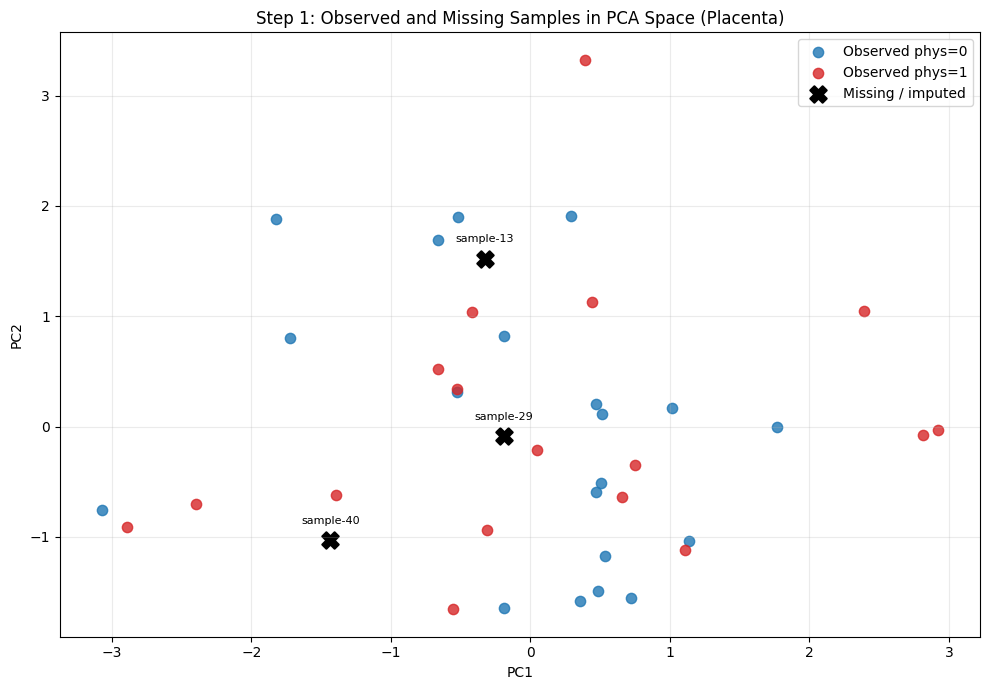

In [19]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

target_col = 'physical_activity'
plot_df = cov_matrix.copy()

target_numeric = pd.to_numeric(plot_df[target_col], errors='coerce')
feature_cols   = [col for col in plot_df.columns if col != target_col]
feature_matrix = plot_df[feature_cols].apply(pd.to_numeric, errors='coerce')
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask  = target_numeric.isna()
use_fallback  = int(missing_mask.sum()) == 0

if use_fallback:
    if fallback_samples:
        missing_mask  = plot_df.index.isin(fallback_samples)
        observed_mask = ~missing_mask
        print('No missing values; showing previously imputed samples as missing markers.')
    else:
        print('No missing values and no fallback samples — all points shown as observed.')
else:
    print(f'Found {int(missing_mask.sum())} missing physical_activity value(s).')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
pca = PCA(n_components=2, random_state=42)
knn_X_2d = pca.fit_transform(scaled_features)

obs_mask  = np.asarray(observed_mask)
miss_mask = np.asarray(missing_mask)
obs_idx   = np.where(obs_mask)[0]
miss_idx  = np.where(miss_mask)[0]
obs_labels = pd.to_numeric(plot_df.loc[observed_mask, target_col], errors='coerce')
zero_idx = np.where(obs_labels.to_numpy() == 0)[0]
one_idx  = np.where(obs_labels.to_numpy() == 1)[0]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(knn_X_2d[obs_idx[zero_idx], 0], knn_X_2d[obs_idx[zero_idx], 1],
           c='#1f77b4', s=55, alpha=0.8, label='Observed phys=0')
ax.scatter(knn_X_2d[obs_idx[one_idx],  0], knn_X_2d[obs_idx[one_idx],  1],
           c='#d62728', s=55, alpha=0.8, label='Observed phys=1')
if miss_idx.size > 0:
    ax.scatter(knn_X_2d[miss_idx, 0], knn_X_2d[miss_idx, 1],
               c='black', marker='X', s=140, linewidths=1.5, label='Missing / imputed')
    for sample, miss_pos in zip(plot_df.index[miss_mask], miss_idx):
        ax.annotate(sample, (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
                    textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8)

ax.set_title('Step 1: Observed and Missing Samples in PCA Space (Placenta)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='best'); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'pca_observed_missing_samples.png'), dpi=150, bbox_inches='tight')
plt.show()


Reconstructing neighbour map for previously imputed samples.


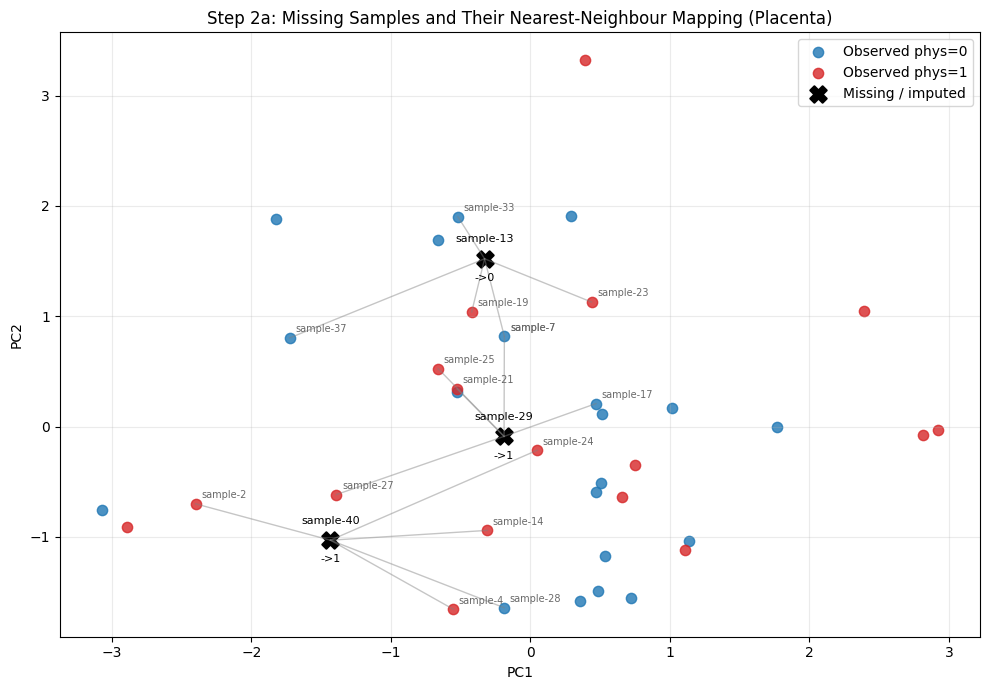

In [20]:
target_col = 'physical_activity'
plot_df = cov_matrix.copy()

target_numeric = pd.to_numeric(plot_df[target_col], errors='coerce')
feature_cols   = [col for col in plot_df.columns if col != target_col]
feature_matrix = plot_df[feature_cols].apply(pd.to_numeric, errors='coerce')
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True)).fillna(0)

observed_mask = target_numeric.notna()
missing_mask  = target_numeric.isna()
use_fallback  = int(missing_mask.sum()) == 0

if use_fallback:
    if fallback_samples:
        missing_mask  = plot_df.index.isin(fallback_samples)
        observed_mask = ~missing_mask
        print('Reconstructing neighbour map for previously imputed samples.')
    else:
        print('No missing values and no fallback samples — nothing to map.')
else:
    print(f'Found {int(missing_mask.sum())} missing physical_activity value(s).')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
pca = PCA(n_components=2, random_state=42)
knn_X_2d = pca.fit_transform(scaled_features)

obs_mask  = np.asarray(observed_mask)
miss_mask = np.asarray(missing_mask)
obs_idx   = np.where(obs_mask)[0]
miss_idx  = np.where(miss_mask)[0]
obs_labels     = pd.to_numeric(plot_df.loc[observed_mask, target_col], errors='coerce')
observed_index = plot_df.index[observed_mask]
missing_index  = plot_df.index[missing_mask]
zero_idx = np.where(obs_labels.to_numpy() == 0)[0]
one_idx  = np.where(obs_labels.to_numpy() == 1)[0]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(knn_X_2d[obs_idx[zero_idx], 0], knn_X_2d[obs_idx[zero_idx], 1],
           c='#1f77b4', s=55, alpha=0.8, label='Observed phys=0')
ax.scatter(knn_X_2d[obs_idx[one_idx],  0], knn_X_2d[obs_idx[one_idx],  1],
           c='#d62728', s=55, alpha=0.8, label='Observed phys=1')

if miss_idx.size > 0:
    n_neighbors = min(5, int(obs_mask.sum()))
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(scaled_features[obs_mask])
    distances, neighbor_positions = nn.kneighbors(scaled_features[miss_mask])

    ax.scatter(knn_X_2d[miss_idx, 0], knn_X_2d[miss_idx, 1],
               c='black', marker='X', s=140, linewidths=1.5, label='Missing / imputed')

    for i, sample in enumerate(missing_index):
        miss_pos       = miss_idx[i]
        nbr_rel        = neighbor_positions[i]
        nbr_abs        = obs_idx[nbr_rel]
        nbr_samples    = observed_index[nbr_rel].tolist()
        nbr_values     = obs_labels.iloc[nbr_rel].to_numpy()
        nbr_dist       = distances[i]
        weights        = 1.0 / np.maximum(nbr_dist, 1e-9)
        weighted_score = float(np.sum(weights * nbr_values) / np.sum(weights))
        assigned_value = int(round(weighted_score))

        ax.annotate(sample, (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
                    textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8)
        for nbr_pos, nbr_name in zip(nbr_abs, nbr_samples):
            ax.plot([knn_X_2d[miss_pos, 0], knn_X_2d[nbr_pos, 0]],
                    [knn_X_2d[miss_pos, 1], knn_X_2d[nbr_pos, 1]],
                    color='gray', alpha=0.45, linewidth=1)
            ax.annotate(nbr_name, (knn_X_2d[nbr_pos, 0], knn_X_2d[nbr_pos, 1]),
                        textcoords='offset points', xytext=(4, 4), fontsize=7, color='dimgray')
        ax.annotate(f'->{assigned_value}', (knn_X_2d[miss_pos, 0], knn_X_2d[miss_pos, 1]),
                    textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8, color='black')

ax.set_title('Step 2a: Missing Samples and Their Nearest-Neighbour Mapping (Placenta)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='best'); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'pca_knn_nearest_neighbours.png'), dpi=150, bbox_inches='tight')
plt.show()


In [21]:
cov_clean.head(40)


,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity
Sample,,,,,,
sample-1,1,38,28.959000,6.150000,17.000000,0
sample-2,0,34,28.040378,4.500000,4.500000,1
sample-3,1,28,25.217359,3.250000,4.500000,1
sample-4,0,28,24.242424,12.500000,12.500000,1
sample-5,1,37,22.375680,8.500000,24.000000,0
sample-6,0,32,20.195578,30.000000,30.000000,1
sample-7,1,33,21.875000,14.650000,21.000000,0
sample-8,0,32,21.303949,14.650000,21.000000,0
sample-9,1,29,25.076193,2.400000,3.650000,0


In [22]:
placenta_clean = placenta_matrix.loc[cov_clean.index]
print(f'Placenta data shape after matching: {placenta_clean.shape}')


Placenta data shape after matching: (40, 897)


In [23]:
print('Data types in cleaned covariate matrix:')
print(cov_clean.dtypes)
print('\nFactor covariate levels:')
print('GDM:', cov_clean['GDM'].cat.categories.tolist())
print('physical_activity:', cov_clean['physical_activity'].cat.categories.tolist())


Data types in cleaned covariate matrix:
GDM                      category
maternal_age                int64
bmi                       float64
diet_protein              float64
diet_fruit_vegetables     float64
physical_activity        category
dtype: object

Factor covariate levels:
GDM: [0, 1]
physical_activity: [0, 1]


In [24]:
placenta_clean.head(40)


,1002002,1004006,107004,108004,108005,108015,109002,109011,1101006,1102005,...,675026,675027,675028,675029,676002,676003,676007,677004,677007,677011
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,1.067250,1.146871,1.005599,0.787917,1.028547,0.901608,1.022227,1.005848,1.017847,0.893673,...,0.992389,0.995633,1.003121,1.015811,1.050298,1.010108,1.008183,0.993579,1.052516,0.991678
sample-2,0.846538,0.985189,1.003932,0.964908,0.992848,1.010751,1.010744,0.999033,0.991056,0.893673,...,1.003757,1.023405,0.983785,1.008291,0.912968,0.985384,0.979877,0.970319,0.902791,1.002502
sample-3,0.928315,0.991967,0.970812,0.787917,1.028489,0.958734,0.995818,1.020683,0.999784,0.893673,...,0.999519,1.003467,0.991889,0.988243,0.986999,1.006392,1.016172,1.001665,1.001421,1.003265
sample-4,1.101470,1.096246,0.997856,0.805863,1.030684,0.928710,0.997960,0.983982,0.995086,0.893673,...,0.972489,0.975934,0.994323,0.986412,0.955030,0.983886,0.979119,0.977793,0.977029,0.979333
sample-5,1.145117,1.172380,1.018498,0.787917,1.043982,0.901608,1.052483,1.000493,0.980575,0.893673,...,1.013411,0.998258,0.999595,1.022783,0.931531,1.026713,1.006994,1.002254,0.899448,1.004080
sample-6,0.888192,0.979079,0.987530,0.842208,0.998219,0.981891,0.953859,1.000069,0.984418,0.893673,...,1.008714,1.025914,1.011896,0.990507,0.996153,1.045145,1.021836,1.001565,1.004630,1.010325
sample-7,0.843581,0.857733,0.986046,0.787917,1.030064,0.946869,0.951210,1.027411,0.980630,0.893673,...,0.980873,0.987156,0.981820,0.988449,0.899427,1.026239,0.987455,1.017515,0.927659,0.987319
sample-8,0.976617,1.000000,1.003070,1.032983,0.987318,1.055413,0.992134,1.021337,0.992979,0.893673,...,1.006461,1.023802,0.998354,1.000396,0.990203,1.004895,1.001123,1.033180,0.985116,1.011579
sample-9,0.876771,0.949525,0.997292,0.787917,1.016083,0.901608,1.005283,1.013268,1.000216,0.893673,...,1.006339,1.009868,1.029730,1.004422,0.997581,1.010955,1.019599,1.010199,0.987445,1.009486


In [25]:
# Steps 6-13: Main loop across all placenta metabolites
metabolite_annotations = list(placenta_clean.columns)

p_store         = []
m_GDM_store     = []
m_non_GDM_store = []
log_fc_store    = []
raw_fc_store    = []

print(f'Starting loop over {len(metabolite_annotations)} metabolites...')
print('This will apply Steps 6-13 to each metabolite.\n')

for i, metabolite_name in enumerate(metabolite_annotations, start=1):
    model_data = pd.concat(
        [placenta_clean[metabolite_name].rename('metabolite'), cov_clean], axis=1
    ).dropna()

    if model_data.empty or model_data['GDM'].nunique() < 2:
        p_store.append(np.nan)
        m_GDM_store.append(np.nan)
        m_non_GDM_store.append(np.nan)
        log_fc_store.append(np.nan)
        raw_fc_store.append(np.nan)
    else:
        formula = 'metabolite ~ GDM + ' + ' + '.join(
            [col for col in cov_clean.columns if col != 'GDM']
        )
        fit = sm.formula.ols(formula, data=model_data).fit()

        gdm_pval = (
            fit.pvalues['GDM[T.1]']
            if 'GDM[T.1]' in fit.pvalues.index
            else fit.pvalues.get('GDM', np.nan)
        )

        m_gdm     = model_data.loc[model_data['GDM'] == 1, 'metabolite'].mean()
        m_non_gdm = model_data.loc[model_data['GDM'] == 0, 'metabolite'].mean()

        log_fc = m_gdm - m_non_gdm if pd.notna(m_gdm) and pd.notna(m_non_gdm) else np.nan
        raw_fc = 2 ** log_fc if pd.notna(log_fc) else np.nan

        p_store.append(gdm_pval)
        m_GDM_store.append(m_gdm)
        m_non_GDM_store.append(m_non_gdm)
        log_fc_store.append(log_fc)
        raw_fc_store.append(raw_fc)

    if i % 100 == 0:
        print(f'  Processed {i} metabolites...')

print(f'\nCompleted loop. Processed {len(metabolite_annotations)} metabolites.')
print(f'  p-values stored: {len(p_store)}')
print(f'  GDM means stored: {len(m_GDM_store)}')
print(f'  Non-GDM means stored: {len(m_non_GDM_store)}')
print(f'  Fold changes stored: {len(raw_fc_store)}')


Starting loop over 897 metabolites...
This will apply Steps 6-13 to each metabolite.

  Processed 100 metabolites...
  Processed 200 metabolites...
  Processed 300 metabolites...
  Processed 400 metabolites...
  Processed 500 metabolites...
  Processed 600 metabolites...
  Processed 700 metabolites...
  Processed 800 metabolites...

Completed loop. Processed 897 metabolites.
  p-values stored: 897
  GDM means stored: 897
  Non-GDM means stored: 897
  Fold changes stored: 897


In [26]:
p_array         = np.array(p_store)
m_gdm_array     = np.array(m_GDM_store)
m_non_gdm_array = np.array(m_non_GDM_store)
log_fc_array    = np.array(log_fc_store)
raw_fc_array    = np.array(raw_fc_store)

print('Results vectors prepared:')
print(f'  p-values: {len(p_array)}')
print(f'  GDM means: {len(m_gdm_array)}')
print(f'  Non-GDM means: {len(m_non_gdm_array)}')
print(f'  Log fold changes: {len(log_fc_array)}')
print(f'  Raw fold changes: {len(raw_fc_array)}')

print(f'\nP-value summary:')
print(f'  Min: {np.nanmin(p_array)}')
print(f'  Max: {np.nanmax(p_array)}')
print(f'  Mean: {np.nanmean(p_array)}')
print(f'  Median: {np.nanmedian(p_array)}')


Results vectors prepared:
  p-values: 897
  GDM means: 897
  Non-GDM means: 897
  Log fold changes: 897
  Raw fold changes: 897

P-value summary:
  Min: 0.0008628741702577717
  Max: 0.9999301144842018
  Mean: 0.47368225684540816
  Median: 0.44517513229842187


In [27]:
from statsmodels.stats.multitest import multipletests

valid_mask = ~np.isnan(p_array)
pvals_adj_bh = np.full(len(p_array), np.nan)

if valid_mask.any():
    _, pvals_adj_bh[valid_mask], _, _ = multipletests(p_array[valid_mask], method='fdr_bh')

reject_bh = ~np.isnan(pvals_adj_bh) & (pvals_adj_bh < 0.05)

print('Benjamini-Hochberg Correction Results:')
print(f'  Number of significant metabolites (FDR < 0.05): {reject_bh.sum()}')
print(f'  Min adjusted p-value: {np.nanmin(pvals_adj_bh)}')
print(f'  Max adjusted p-value: {np.nanmax(pvals_adj_bh)}')
print(f'  Mean adjusted p-value: {np.nanmean(pvals_adj_bh)}')
print(f'  Median adjusted p-value: {np.nanmedian(pvals_adj_bh)}')


Benjamini-Hochberg Correction Results:
  Number of significant metabolites (FDR < 0.05): 0
  Min adjusted p-value: 0.5257240355085334
  Max adjusted p-value: 0.9999301144842018
  Mean adjusted p-value: 0.8860061790373713
  Median adjusted p-value: 0.8874440401338647


In [28]:
try:
    from qvalue import qvalue
    q_vals = qvalue(p_array)['qvalues']
    print('Q-values calculated using qvalue package')
except ImportError:
    print('qvalue package not available, using BH adjusted p-values as approximation')
    q_vals = pvals_adj_bh

print(f'\nQ-value Summary:')
print(f'  Min: {np.nanmin(q_vals)}')
print(f'  Max: {np.nanmax(q_vals)}')
print(f'  Mean: {np.nanmean(q_vals)}')
print(f'  Median: {np.nanmedian(q_vals)}')


qvalue package not available, using BH adjusted p-values as approximation

Q-value Summary:
  Min: 0.5257240355085334
  Max: 0.9999301144842018
  Mean: 0.8860061790373713
  Median: 0.8874440401338647


In [29]:
if 'metabolite_names' in globals():
    metabolite_names_local = metabolite_names
else:
    metabolite_names_local = metabolite_annotations

if PLACENTA_ANNO is not None and os.path.exists(PLACENTA_ANNO):
    anno_df = pd.read_csv(PLACENTA_ANNO, index_col=0)
else:
    anno_df = None

results_df = pd.DataFrame({
    'Metabolite': metabolite_names_local,
    'p_value_raw': p_array,
    'p_value_corrected': pvals_adj_bh,
    'q_value': q_vals,
    'Mean_GDM': m_gdm_array,
    'Mean_Non_GDM': m_non_gdm_array,
    'Log_Fold_Change': log_fc_array,
    'Raw_Fold_Change': raw_fc_array,
})

if anno_df is not None:
    anno_mapping = anno_df.to_dict('index')
    annotation_cols = [
        anno_mapping.get(met, {col: None for col in anno_df.columns})
        for met in metabolite_names_local
    ]
    anno_expanded = pd.DataFrame(annotation_cols)
    results_df = pd.concat([results_df, anno_expanded], axis=1)

results_df = results_df.sort_values('p_value_raw')

print('Results Table Summary:')
print(f'  Total metabolites: {len(results_df)}')
print(f'\nFirst 10 rows (sorted by p-value):')
results_df.head(10)


Results Table Summary:
  Total metabolites: 897

First 10 rows (sorted by p-value):


,Metabolite,p_value_raw,p_value_corrected,q_value,Mean_GDM,Mean_Non_GDM,Log_Fold_Change,Raw_Fold_Change,COMPOUND Name,SUPER META PATHWAY,SUB META PATHWAY,ACQUISITION METHOD,HMDB ID,HMDB_annotation,PUBCHEM ID,CAS ID,KEGG ID,CHEMSPIDER ID
724,607021,0.000863,0.525724,0.525724,1.003155,0.981819,0.021336,1.014899,palmitoyl-arachidonoyl-glycerol (16:0/20:4) [1]*,Lipid,Diacylglycerol,POSb,NaN,NaN,NaN,NaN,NaN,NaN
846,654002,0.002116,0.525724,0.525724,1.004386,0.986075,0.018311,1.012773,1-palmitoyl-2-arachidonoyl-GPS (16:0/20:4),Lipid,Phosphatidylserine (PS),POSb,NaN,NaN,NaN,NaN,NaN,NaN
741,612028,0.002597,0.525724,0.525724,1.013054,0.990692,0.022362,1.015621,stearoyl ethanolamide,Lipid,Endocannabinoid,POSb,HMDB0013078,NaN,27902.0,111-57-9,NaN,25958.0
740,612001,0.002922,0.525724,0.525724,1.020387,0.981985,0.038402,1.026976,arachidonoyl ethanolamide,Lipid,Endocannabinoid,POSb,HMDB0004080,NaN,NaN,NaN,C11695,NaN
725,607022,0.002930,0.525724,0.525724,1.002006,0.988184,0.013822,1.009627,palmitoyl-arachidonoyl-glycerol (16:0/20:4) [2]*,Lipid,Diacylglycerol,POSb,HMDB0007112,NaN,9543736.0,NaN,C00165,7822686.0
722,607014,0.004636,0.604544,0.604544,1.003581,0.988397,0.015184,1.010581,oleoyl-arachidonoyl-glycerol (18:1/20:4) [2]*,Lipid,Diacylglycerol,POSb,HMDB0007228,NaN,9543786.0,NaN,NaN,NaN
729,607031,0.004853,0.604544,0.604544,0.998285,0.992643,0.005642,1.003918,stearoyl-arachidonoyl-glycerol (18:0/20:4) [2]*,Lipid,Diacylglycerol,POSb,HMDB0007170,NaN,6438587.0,NaN,C00165,4943054.0
718,607005,0.005994,0.604544,0.604544,1.003075,0.979414,0.023661,1.016536,linoleoyl-arachidonoyl-glycerol (18:2/20:4) [1]*,Lipid,Diacylglycerol,POSb,NaN,NaN,NaN,NaN,NaN,NaN
878,675017,0.006188,0.604544,0.604544,1.007984,0.987874,0.020110,1.014037,"sphingomyelin (d18:1/22:2, d18:2/22:1, d16:1/2...",Lipid,Sphingomyelins,POSb,HMDB0240670,"HMDB0240670,HMDB0240669(SM(d18:2(4E,14Z)/22:1(...",NaN,1612873-57-0,NaN,NaN
224,646012,0.007379,0.604544,0.604544,0.973827,0.950933,0.022894,1.015996,1-oleoylglycerol (18:1),Lipid,Monoacylglycerol,NEGa,HMDB0011567,NaN,12178130.0,129784-87-8,NaN,23010051.0


In [30]:
save_path = os.path.join(pl_csv_dir, 'Linear_Model_data.csv')
results_df.to_csv(save_path, index=False)
print(f'Saved results to: {save_path}')
print(f'Rows: {len(results_df)}, Columns: {results_df.shape[1]}')


Saved results to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/Linear_Model_data.csv
Rows: 897, Columns: 18


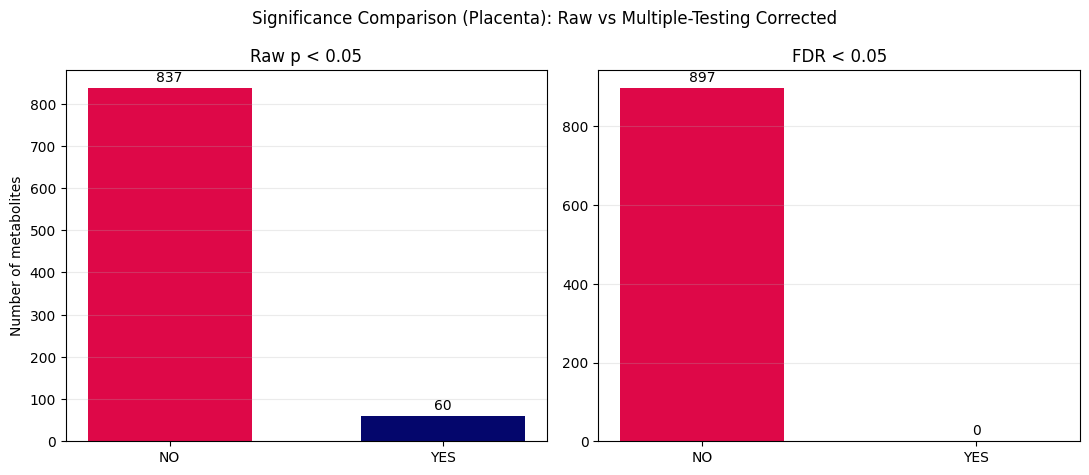

Raw p<0.05: 60/897
FDR<0.05: 0/897


In [31]:
alpha = 0.05
cmp_df = results_df[['p_value_raw', 'p_value_corrected']].dropna().copy()

n_total_cmp = len(cmp_df)
raw_yes = int((cmp_df['p_value_raw']       < alpha).sum())
raw_no  = n_total_cmp - raw_yes
fdr_yes = int((cmp_df['p_value_corrected'] < alpha).sum())
fdr_no  = n_total_cmp - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

bars1 = axes[0].bar(['NO', 'YES'], [raw_no, raw_yes], color=['#de0848', '#04066c'], width=0.6)
axes[0].set_title(f'Raw p < {alpha}')
axes[0].set_ylabel('Number of metabolites')
axes[0].grid(axis='y', alpha=0.25)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp*0.01),
                 f'{int(b.get_height())}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(['NO', 'YES'], [fdr_no, fdr_yes], color=['#de0848', '#a018d2'], width=0.6)
axes[1].set_title(f'FDR < {alpha}')
axes[1].grid(axis='y', alpha=0.25)
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp*0.01),
                 f'{int(b.get_height())}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Significance Comparison (Placenta): Raw vs Multiple-Testing Corrected', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'significance_comparison_alpha_0_05.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Raw p<{alpha}: {raw_yes}/{n_total_cmp}')
print(f'FDR<{alpha}: {fdr_yes}/{n_total_cmp}')


In [32]:
metabolites_p05 = results_df[
    results_df['p_value_raw'] < 0.05
][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change',
   'Mean_GDM', 'Mean_Non_GDM']].reset_index(drop=True)

print(f"{'='*100}")
print(f'SIGNIFICANT METABOLITES (Raw p < 0.05): {len(metabolites_p05)} metabolites')
print(f"{'='*100}\n")

for idx, row in metabolites_p05.iterrows():
    print(f"{idx+1:3d}. {str(row['Metabolite']):>10s}  |  "
          f"Raw p: {row['p_value_raw']:.6f}  |  "
          f"FDR: {row['p_value_corrected']:.4f}  |  "
          f"Log FC: {row['Log_Fold_Change']:>7.4f}  |  "
          f"Mean GDM: {row['Mean_GDM']:.4f}  |  Mean Non-GDM: {row['Mean_Non_GDM']:.4f}")

p05_path = os.path.join(pl_csv_dir, 'metabolites_raw_p_lt_0_05.csv')
metabolites_p05.to_csv(p05_path, index=False)
print(f'\nSaved to: {p05_path}')


SIGNIFICANT METABOLITES (Raw p < 0.05): 60 metabolites

  1.     607021  |  Raw p: 0.000863  |  FDR: 0.5257  |  Log FC:  0.0213  |  Mean GDM: 1.0032  |  Mean Non-GDM: 0.9818
  2.     654002  |  Raw p: 0.002116  |  FDR: 0.5257  |  Log FC:  0.0183  |  Mean GDM: 1.0044  |  Mean Non-GDM: 0.9861
  3.     612028  |  Raw p: 0.002597  |  FDR: 0.5257  |  Log FC:  0.0224  |  Mean GDM: 1.0131  |  Mean Non-GDM: 0.9907
  4.     612001  |  Raw p: 0.002922  |  FDR: 0.5257  |  Log FC:  0.0384  |  Mean GDM: 1.0204  |  Mean Non-GDM: 0.9820
  5.     607022  |  Raw p: 0.002930  |  FDR: 0.5257  |  Log FC:  0.0138  |  Mean GDM: 1.0020  |  Mean Non-GDM: 0.9882
  6.     607014  |  Raw p: 0.004636  |  FDR: 0.6045  |  Log FC:  0.0152  |  Mean GDM: 1.0036  |  Mean Non-GDM: 0.9884
  7.     607031  |  Raw p: 0.004853  |  FDR: 0.6045  |  Log FC:  0.0056  |  Mean GDM: 0.9983  |  Mean Non-GDM: 0.9926
  8.     607005  |  Raw p: 0.005994  |  FDR: 0.6045  |  Log FC:  0.0237  |  Mean GDM: 1.0031  |  Mean Non-GDM: 0.9794


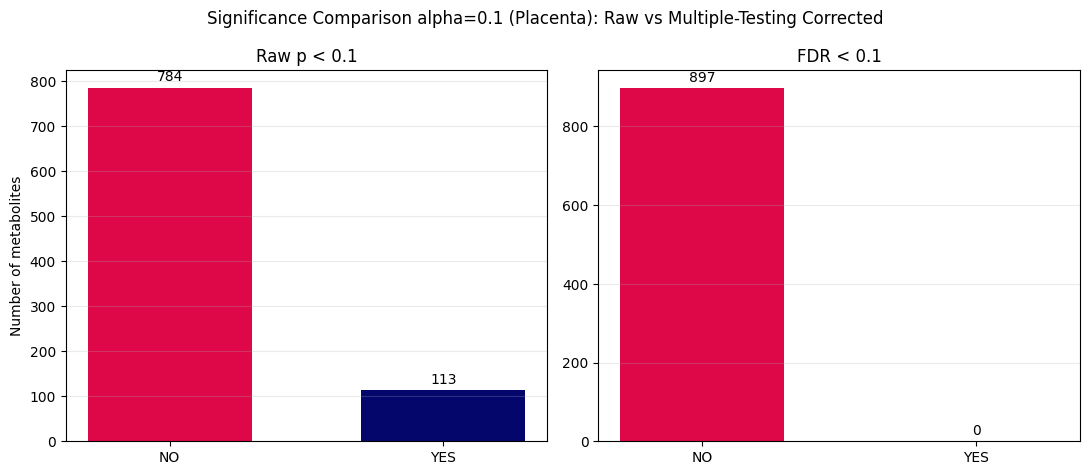

Raw p<0.1: 113/897
FDR<0.1: 0/897


In [33]:
alpha = 0.1
cmp_df = results_df[['p_value_raw', 'p_value_corrected']].dropna().copy()

n_total_cmp = len(cmp_df)
raw_yes = int((cmp_df['p_value_raw']       < alpha).sum())
raw_no  = n_total_cmp - raw_yes
fdr_yes = int((cmp_df['p_value_corrected'] < alpha).sum())
fdr_no  = n_total_cmp - fdr_yes

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

bars1 = axes[0].bar(['NO', 'YES'], [raw_no, raw_yes], color=['#de0848', '#04066c'], width=0.6)
axes[0].set_title(f'Raw p < {alpha}')
axes[0].set_ylabel('Number of metabolites')
axes[0].grid(axis='y', alpha=0.25)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp*0.01),
                 f'{int(b.get_height())}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(['NO', 'YES'], [fdr_no, fdr_yes], color=['#de0848', '#a018d2'], width=0.6)
axes[1].set_title(f'FDR < {alpha}')
axes[1].grid(axis='y', alpha=0.25)
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + max(1, n_total_cmp*0.01),
                 f'{int(b.get_height())}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Significance Comparison alpha=0.1 (Placenta): Raw vs Multiple-Testing Corrected', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'significance_comparison_alpha_0_10.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Raw p<{alpha}: {raw_yes}/{n_total_cmp}')
print(f'FDR<{alpha}: {fdr_yes}/{n_total_cmp}')


In [34]:
metabolites_p10 = results_df[
    results_df['p_value_raw'] < 0.1
][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change',
   'Mean_GDM', 'Mean_Non_GDM']].reset_index(drop=True)

print(f"{'='*100}")
print(f'SIGNIFICANT METABOLITES (Raw p < 0.1): {len(metabolites_p10)} metabolites')
print(f"{'='*100}\n")

for idx, row in metabolites_p10.iterrows():
    print(f"{idx+1:3d}. {str(row['Metabolite']):>10s}  |  "
          f"Raw p: {row['p_value_raw']:.6f}  |  "
          f"FDR: {row['p_value_corrected']:.4f}  |  "
          f"Log FC: {row['Log_Fold_Change']:>7.4f}  |  "
          f"Mean GDM: {row['Mean_GDM']:.4f}  |  Mean Non-GDM: {row['Mean_Non_GDM']:.4f}")

p10_path = os.path.join(pl_csv_dir, 'metabolites_raw_p_lt_0_1_detailed.csv')
metabolites_p10.to_csv(p10_path, index=False)
print(f'\nSaved to: {p10_path}')


SIGNIFICANT METABOLITES (Raw p < 0.1): 113 metabolites

  1.     607021  |  Raw p: 0.000863  |  FDR: 0.5257  |  Log FC:  0.0213  |  Mean GDM: 1.0032  |  Mean Non-GDM: 0.9818
  2.     654002  |  Raw p: 0.002116  |  FDR: 0.5257  |  Log FC:  0.0183  |  Mean GDM: 1.0044  |  Mean Non-GDM: 0.9861
  3.     612028  |  Raw p: 0.002597  |  FDR: 0.5257  |  Log FC:  0.0224  |  Mean GDM: 1.0131  |  Mean Non-GDM: 0.9907
  4.     612001  |  Raw p: 0.002922  |  FDR: 0.5257  |  Log FC:  0.0384  |  Mean GDM: 1.0204  |  Mean Non-GDM: 0.9820
  5.     607022  |  Raw p: 0.002930  |  FDR: 0.5257  |  Log FC:  0.0138  |  Mean GDM: 1.0020  |  Mean Non-GDM: 0.9882
  6.     607014  |  Raw p: 0.004636  |  FDR: 0.6045  |  Log FC:  0.0152  |  Mean GDM: 1.0036  |  Mean Non-GDM: 0.9884
  7.     607031  |  Raw p: 0.004853  |  FDR: 0.6045  |  Log FC:  0.0056  |  Mean GDM: 0.9983  |  Mean Non-GDM: 0.9926
  8.     607005  |  Raw p: 0.005994  |  FDR: 0.6045  |  Log FC:  0.0237  |  Mean GDM: 1.0031  |  Mean Non-GDM: 0.9794


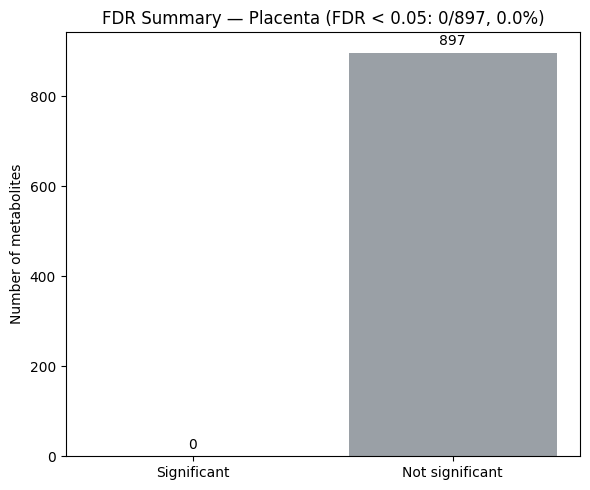

Conclusion: No statistically significant placenta metabolite differences detected between GDM-positive and non-GDM women at FDR < 0.05.


In [35]:
plot_df2 = results_df.dropna(subset=['Log_Fold_Change', 'p_value_corrected']).copy()
plot_df2['neg_log10_fdr'] = -np.log10(np.clip(plot_df2['p_value_corrected'].astype(float), 1e-300, 1.0))
plot_df2['significant_fdr'] = plot_df2['p_value_corrected'].astype(float) < 0.05

sig_n     = int(plot_df2['significant_fdr'].sum())
non_sig_n = int((~plot_df2['significant_fdr']).sum())
total_n   = sig_n + non_sig_n
sig_pct   = (100 * sig_n / total_n) if total_n else 0.0

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Significant', 'Not significant'], [sig_n, non_sig_n], color=['#d1495b', '#9aa0a6'])
ax.set_ylabel('Number of metabolites')
ax.set_title(f'FDR Summary — Placenta (FDR < 0.05: {sig_n}/{total_n}, {sig_pct:.1f}%)')
for i, v in enumerate([sig_n, non_sig_n]):
    ax.text(i, v + max(1, total_n * 0.01), str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(pl_img_dir, 'fdr_summary_bar_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

if sig_n > 0:
    print(f'Conclusion: {sig_n} placenta metabolites are significantly different between GDM-positive and non-GDM women at FDR < 0.05.')
else:
    print('Conclusion: No statistically significant placenta metabolite differences detected between GDM-positive and non-GDM women at FDR < 0.05.')


In [36]:
placenta_clean_export = os.path.join(pl_csv_dir, 'placenta_clean_from_python.csv')
cov_clean_export      = os.path.join(pl_csv_dir, 'cov_clean_from_python.csv')

placenta_clean.to_csv(placenta_clean_export, index=True, index_label='Sample')
cov_clean.to_csv(cov_clean_export,           index=True, index_label='Sample')

print(f'Saved placenta_clean to: {placenta_clean_export}')
print(f'Saved cov_clean to:      {cov_clean_export}')
print(f'placenta_clean shape: {placenta_clean.shape}')
print(f'cov_clean shape:      {cov_clean.shape}')


Saved placenta_clean to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/placenta_clean_from_python.csv
Saved cov_clean to:      /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/cov_clean_from_python.csv
placenta_clean shape: (40, 897)
cov_clean shape:      (40, 6)


In [37]:
metabolites_raw_p_01 = results_df[results_df['p_value_raw'] < 0.1]['Metabolite'].tolist()

txt_path = os.path.join(pl_csv_dir, 'metabolites_raw_p_lt_0_1.txt')
with open(txt_path, 'w') as f:
    for metabolite in metabolites_raw_p_01:
        f.write(f'{metabolite}\n')

print(f'Saved {len(metabolites_raw_p_01)} metabolite names to: {txt_path}')
print('\nFirst 10 metabolite names:')
for i, met in enumerate(metabolites_raw_p_01[:10], 1):
    print(f'  {i}. {met}')


Saved 113 metabolite names to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/metabolites_raw_p_lt_0_1.txt

First 10 metabolite names:
  1. 607021
  2. 654002
  3. 612028
  4. 612001
  5. 607022
  6. 607014
  7. 607031
  8. 607005
  9. 675017
  10. 646012


In [38]:
metabolites_df = results_df[
    results_df['p_value_raw'] < 0.1
][['Metabolite', 'p_value_raw', 'p_value_corrected', 'Log_Fold_Change']].reset_index(drop=True)
metabolites_df.index.name = 'Index'
metabolites_df = metabolites_df.reset_index()

csv_path = os.path.join(pl_csv_dir, 'metabolites_raw_p_lt_0_1.csv')
metabolites_df.to_csv(csv_path, index=False)

print(f'Saved metabolites (raw p < 0.1) table to: {csv_path}')
print(f'Table shape: {metabolites_df.shape}')
print('\nFirst 10 rows:')
print(metabolites_df.head(10))


Saved metabolites (raw p < 0.1) table to: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/Placenta/Python_outputs/CSV/metabolites_raw_p_lt_0_1.csv
Table shape: (113, 5)

First 10 rows:
   Index Metabolite  p_value_raw  p_value_corrected  Log_Fold_Change
0      0     607021     0.000863           0.525724         0.021336
1      1     654002     0.002116           0.525724         0.018311
2      2     612028     0.002597           0.525724         0.022362
3      3     612001     0.002922           0.525724         0.038402
4      4     607022     0.002930           0.525724         0.013822
5      5     607014     0.004636           0.604544         0.015184
6      6     607031     0.004853           0.604544         0.005642
7      7     607005     0.005994           0.604544         0.023661
8      8     675017     0.006188           0.604544         0.020110
9      9     646012     0.007